# Per-tier ω sweeps (B/C) + 303×317 interaction maps

Prompt 20 Tasks 1–2 (math-log §4.1/§4.3). Data: `waves/sweep_{B,C}` —
per-tier OAT ω sweeps, 6 tiers × 9 levels × 2 scenarios (ρ = 1.5, 2.0) —
and `waves/contour_303x317_{B,C}` for the pair surfaces. Scenario A has
**no sweep wave**, so no interaction map is computable for A (stated, not
faked).

Conventions: Δ metrics are vs the full-year base case (negative =
improvement). M = 4 headline metrics = {cost APPROX, curtailment, load
shed, thermal starts}; **reserve shortfall is a diagnostic only** (shown
in curves, excluded from headline/optimum language). Noise floors:
shed ±3,000 MWh; curtailment ~5,000 MWh; cost ~$0.5M; reserve/starts have
no stated floor.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
plt.rcParams.update({"font.weight": "bold", "axes.labelweight": "bold", "axes.titleweight": "bold"})
import numpy as np
import pandas as pd

_here = Path.cwd().resolve()
CAMP = next(p for p in [_here, *_here.parents] if (p / "waves" / "screening").is_dir())
OUT = CAMP / "analysis" / "sweep_0910"
FIGS = OUT / "figs"
FIGS.mkdir(parents=True, exist_ok=True)

TIERS = ["nuclear", "wind_303", "wind_317", "wind_122", "pv", "tail"]
SCEN = {"B": 1.5, "C": 2.0}

# metric vocabulary (prompt 20): M = 4 headline + reserve diagnostic + H2
METRICS = {
    "delta_cost_less_synthetic_usd_APPROX": ("Δ cost APPROX [M$/yr]", 1e-6, 0.5),
    "delta_curtailment_mwh": ("Δ curtailment [GWh/yr]", 1e-3, 5.0),
    "delta_load_shed_mwh": ("Δ load shed [GWh/yr]", 1e-3, 3.0),
    "delta_thermal_starts": ("Δ thermal starts [/yr]", 1.0, None),
    "delta_reserve_shortfall_mwh": ("Δ reserve shortfall [GWh/yr]\n(diagnostic)", 1e-3, None),
    "h2_kg_total": ("H2 production [kt/yr]", 1e-6, None),
}
M4 = list(METRICS)[:4]
# single-measurement noise floors in NATIVE units (None = no stated floor)
FLOOR = {"delta_cost_less_synthetic_usd_APPROX": 0.5e6,
         "delta_curtailment_mwh": 5000.0,
         "delta_load_shed_mwh": 3000.0,
         "delta_thermal_starts": None}

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "savefig.facecolor": "white", "axes.labelweight": "bold",
    "font.size": 10,
})


def save(fig, name):
    fig.savefig(FIGS / f"{name}.png", dpi=200, bbox_inches="tight")
    fig.savefig(FIGS / f"{name}.pdf", bbox_inches="tight")
    print(f"saved figs/{name}.png + .pdf")


def load_sweep(s):
    dm = pd.read_csv(CAMP / "waves" / f"sweep_{s}" / "design_matrix.csv")
    ob = pd.read_csv(CAMP / "waves" / f"sweep_{s}" / "objectives.csv")
    df = dm.merge(ob[["index"] + list(METRICS)], on="index")
    oc = [f"{t}_omega" for t in TIERS]
    active = df[oc].notna()
    assert (active.sum(axis=1) == 1).all(), "each sweep row activates exactly one tier"
    df["tier"] = active.idxmax(axis=1).str.replace("_omega", "", regex=False)
    df["omega"] = [df.loc[i, f"{df.loc[i, 'tier']}_omega"] for i in df.index]
    return df


def load_pair(s):
    w = CAMP / "waves" / f"contour_303x317_{s}"
    df = pd.read_csv(w / "design_matrix.csv")[
        ["index", "wind_303_omega", "wind_317_omega"]
    ].merge(pd.read_csv(w / "objectives.csv"), on="index")
    assert len(df) == 81
    return df


sweep = {s: load_sweep(s) for s in SCEN}
pair = {s: load_pair(s) for s in SCEN}

# assert 6 tiers x 9 levels x 2 scenarios
for s, df in sweep.items():
    assert len(df) == 54
    counts = df.groupby("tier")["omega"].nunique()
    assert set(counts.index) == set(TIERS) and (counts == 9).all(), counts

# grid alignment (verified in 19b/prompt 20 — assert so future data trips it):
# the sweep wind omega levels equal the contour lattice EXACTLY (bitwise)
lat303 = np.unique(pair["B"]["wind_303_omega"])
lat317 = np.unique(pair["B"]["wind_317_omega"])
for s, df in sweep.items():
    for t, lat in (("wind_303", lat303), ("wind_317", lat317)):
        sw = np.sort(df.loc[df.tier == t, "omega"].to_numpy())
        assert np.array_equal(sw, lat), f"sweep {s} {t} levels drifted off the contour lattice"
print("asserts OK: 6 tiers x 9 levels x 2 scenarios; wind levels == contour lattice (bitwise)")


asserts OK: 6 tiers x 9 levels x 2 scenarios; wind levels == contour lattice (bitwise)


## Task 1 — g(ω) per tier × metric

Two lines per panel (ρ = 1.5 solid, ρ = 2.0 dashed). Each panel's x-range
is the tier's ω-box (annotated in the row label). The nuclear cost panel
carries the mandatory APPROX caveat (living report §3.4).


saved figs/sweep_curves_grid.png + .pdf


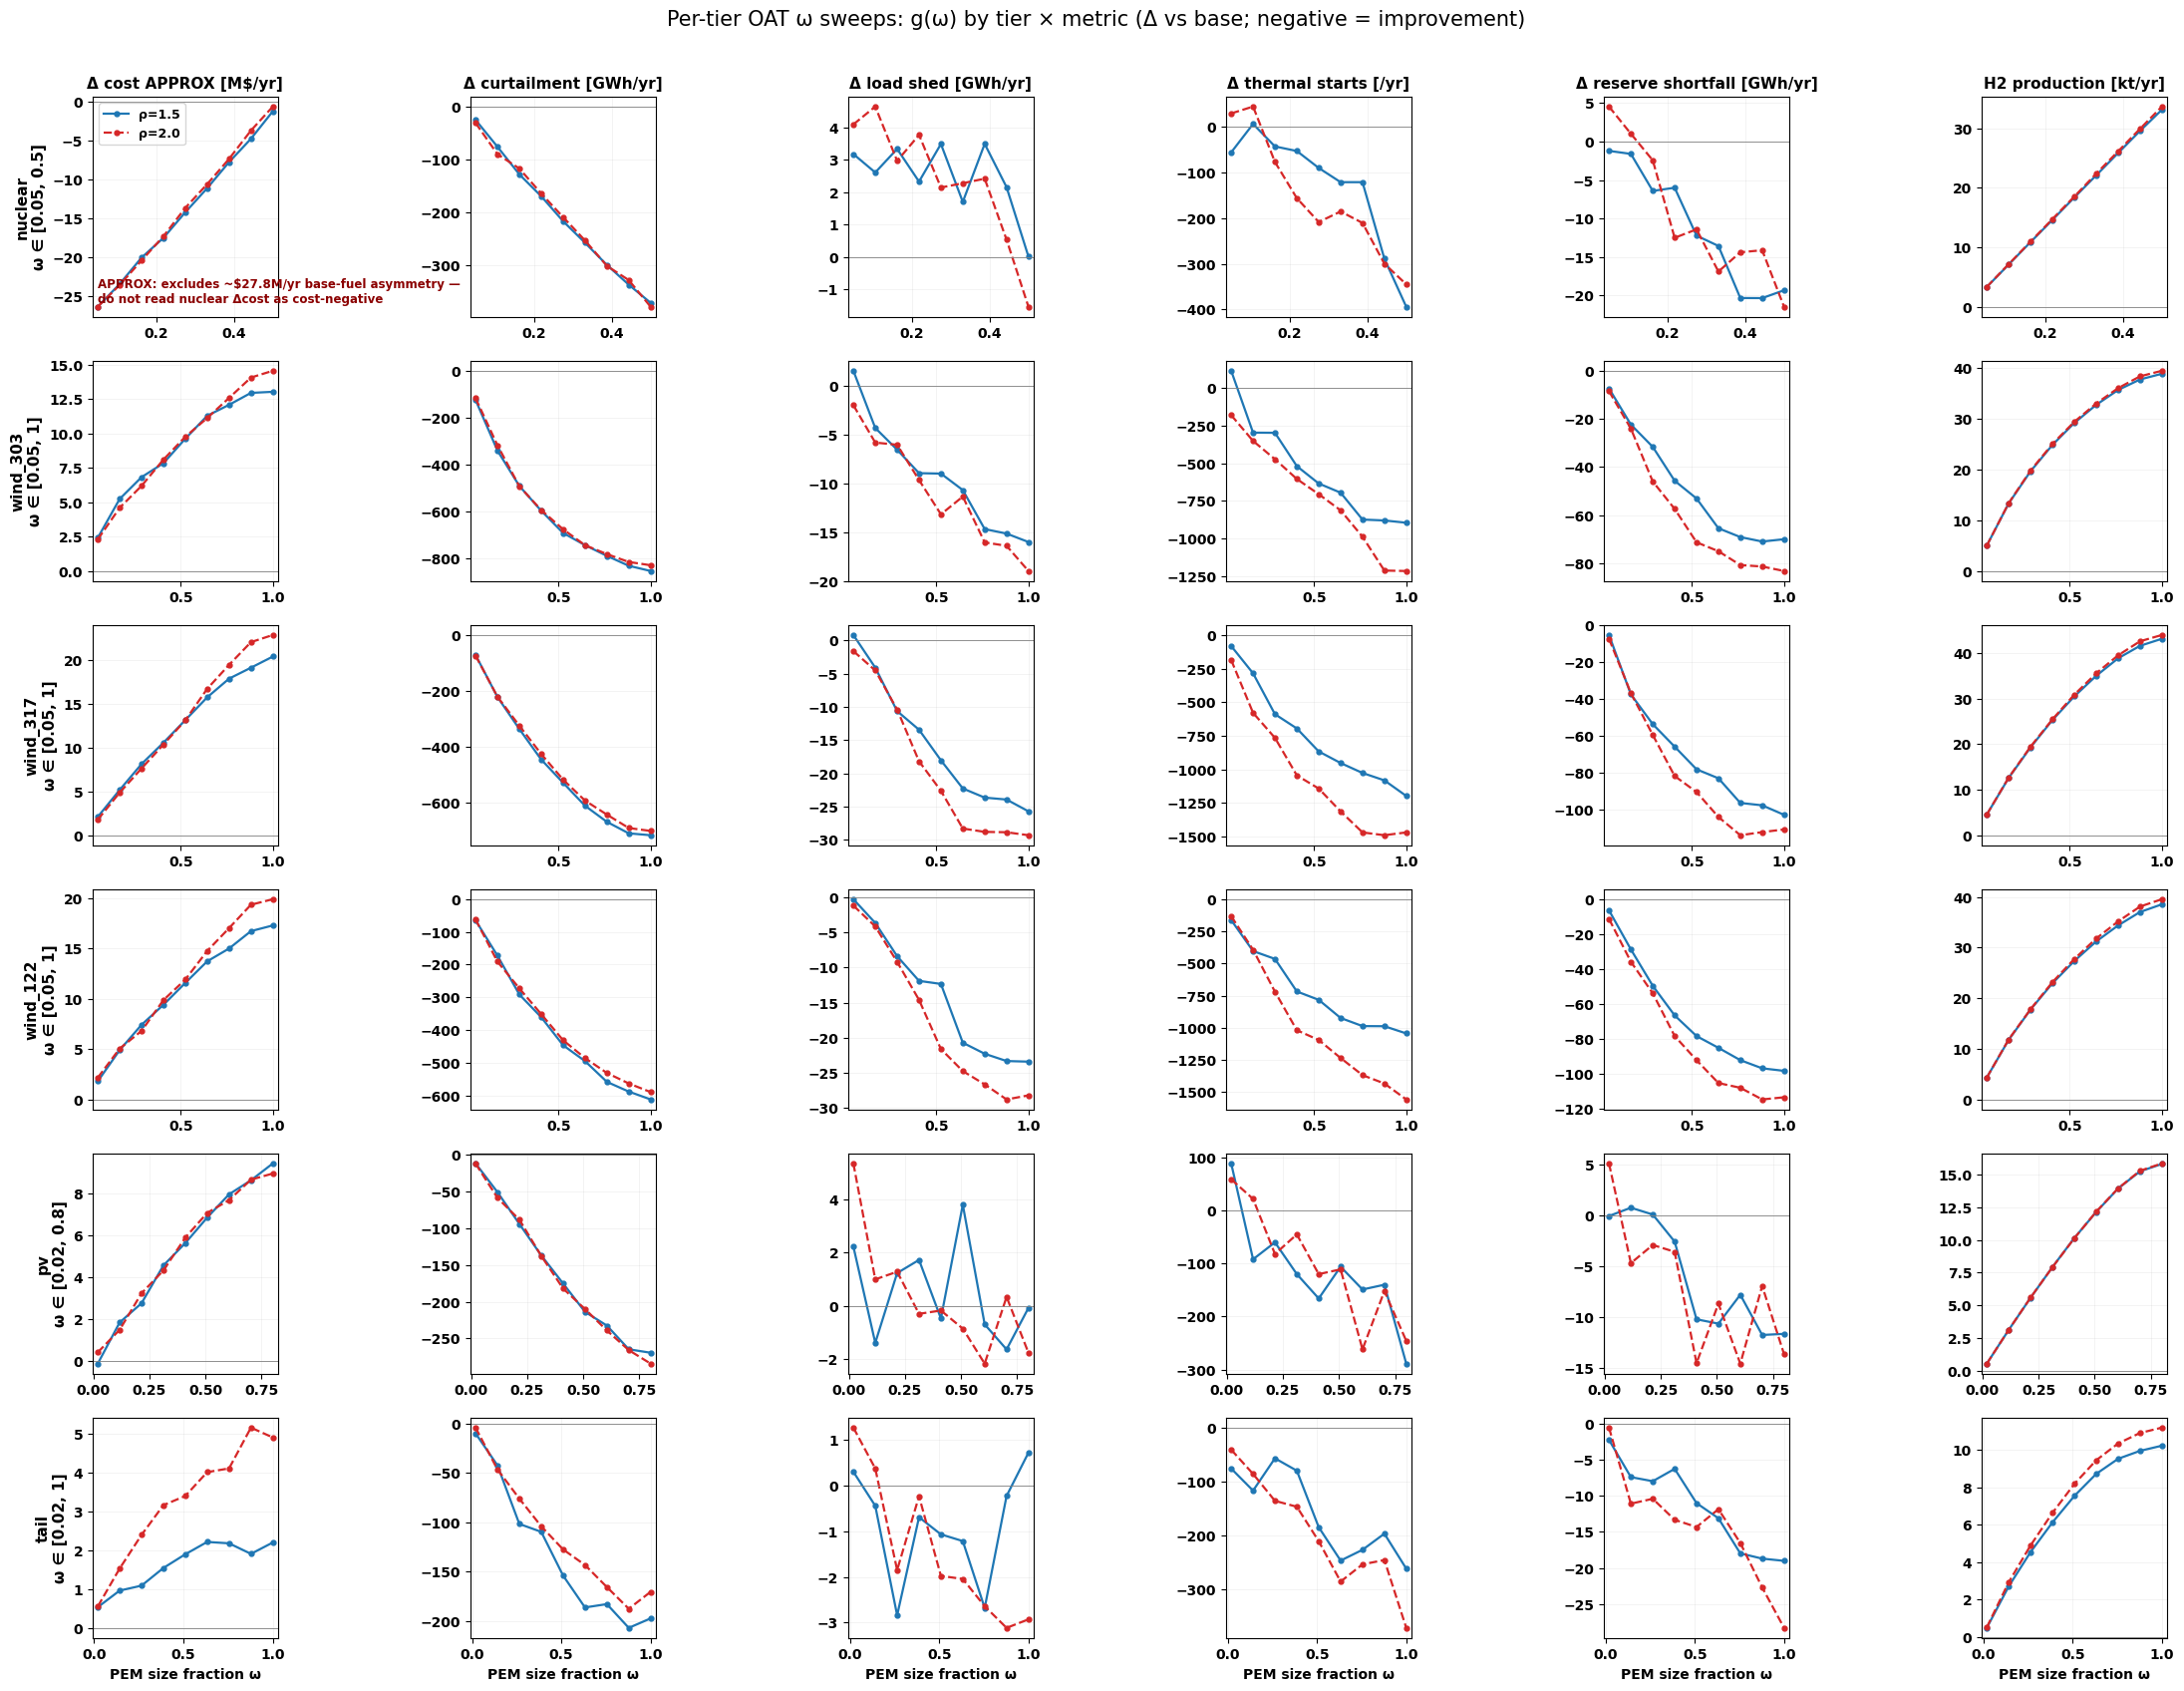

In [2]:
BOX = {t: (sweep["B"][sweep["B"].tier == t]["omega"].min(),
           sweep["B"][sweep["B"].tier == t]["omega"].max()) for t in TIERS}

fig, axes = plt.subplots(len(TIERS), len(METRICS), figsize=(22, 17),
                         sharex="row")
for i, t in enumerate(TIERS):
    for j, (col, (label, scale, _)) in enumerate(METRICS.items()):
        ax = axes[i, j]
        for s, (ls, c) in zip(SCEN, [("-", "tab:blue"), ("--", "tab:red")]):
            g = sweep[s][sweep[s].tier == t].sort_values("omega")
            ax.plot(g["omega"], g[col] * scale, ls, color=c, marker="o",
                    ms=3.5, lw=1.6, label=f"ρ={SCEN[s]}")
        lo, hi = BOX[t]
        ax.set_xlim(lo - 0.03 * (hi - lo), hi + 0.03 * (hi - lo))
        ax.axhline(0, color="grey", lw=0.6)
        ax.grid(alpha=0.25, lw=0.4)
        if i == 0:
            ax.set_title(label.splitlines()[0], fontsize=11, fontweight="bold")
        if j == 0:
            ax.set_ylabel(f"{t}\nω ∈ [{lo:g}, {hi:g}]", fontsize=11,
                          fontweight="bold")
        if i == len(TIERS) - 1:
            ax.set_xlabel("PEM size fraction ω", fontweight="bold")
        if i == 0 and j == 0:
            ax.legend(fontsize=9, frameon=True)
        if t == "nuclear" and col == "delta_cost_less_synthetic_usd_APPROX":
            ax.text(0.03, 0.05,
                    "APPROX: excludes ~$27.8M/yr base-fuel asymmetry —\n"
                    "do not read nuclear Δcost as cost-negative",
                    transform=ax.transAxes, fontsize=8.5, color="darkred",
                    va="bottom")
fig.suptitle("Per-tier OAT ω sweeps: g(ω) by tier × metric (Δ vs base; negative = improvement)",
             fontsize=15, y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.985))
save(fig, "sweep_curves_grid")
plt.show()


In [3]:
def quantify(df, col):
    """Per tier: marginal slope over the first 3 levels, saturation omega
    (first omega where remaining improvement < 10% of the tier's total
    span), and the total effect (value at the box top)."""
    out = {}
    for t in TIERS:
        g = df[df.tier == t].sort_values("omega")
        w, y = g["omega"].to_numpy(), g[col].to_numpy()
        slope = (y[2] - y[0]) / (w[2] - w[0])
        span = y[-1] - y[0]
        floor = FLOOR.get(col)
        if floor is not None and abs(y[-1]) < floor:
            sat = np.nan  # total effect below noise floor: saturation undefined
        else:
            rem = np.abs(y[-1] - y)
            k = np.argmax(rem < 0.10 * abs(span)) if abs(span) > 0 else 0
            sat = w[k]
        out[t] = dict(total=y[-1], slope3=slope, sat_omega=sat)
    return pd.DataFrame(out).T


tables = {}
for s in SCEN:
    for col in list(METRICS)[:5]:  # M4 + reserve diagnostic
        tables[(s, col)] = quantify(sweep[s], col)

print("=== total effect at box top / marginal slope (first 3 levels) / saturation omega ===")
for col in M4:
    _, scale, _ = METRICS[col]
    print(f"\n--- {col} ---")
    tab = pd.concat({s: tables[(s, col)] for s in SCEN}, axis=1)
    print((tab * 1).round(3).to_string())

print("\n=== tier ranking by |total effect| (headline metrics) ===")
RANK = {}
for s in SCEN:
    for col in M4:
        floor = FLOOR.get(col)
        tt = tables[(s, col)]["total"]
        above = tt[tt.abs() >= (floor or 0)]
        RANK[(s, col)] = list(above.abs().sort_values(ascending=False).index)
        below = [t for t in TIERS if t not in RANK[(s, col)]]
        print(f"{s} {col[:36]:<38} " + " > ".join(RANK[(s, col)])
              + (f"   [below floor: {', '.join(below)}]" if below else ""))

print("\nScreening (B=$40, omega=0.5) solo Δcurt ranking was 303 > 317 > 122 "
      "(671.6 / 498.7 / 416.6 GWh) — the sweeps reproduce the same top-heavy "
      "wind order at both prices.")


=== total effect at box top / marginal slope (first 3 levels) / saturation omega ===

--- delta_cost_less_synthetic_usd_APPROX ---
                     B                                     C                        
                 total        slope3 sat_omega         total        slope3 sat_omega
nuclear  -1.195985e+06  5.613620e+07     0.500 -5.923326e+05  5.287332e+07     0.500
wind_303  1.303664e+07  1.857544e+07     0.762  1.456580e+07  1.639053e+07     0.881
wind_317  2.040287e+07  2.538580e+07     0.881  2.286413e+07  2.462620e+07     0.881
wind_122  1.729228e+07  2.363062e+07     0.881  1.989974e+07  1.957420e+07     0.881
pv        9.411446e+06  1.476971e+07     0.702  8.930860e+06  1.444521e+07     0.702
tail      2.202870e+06  2.267766e+06     0.633  4.911385e+06  7.538971e+06     0.878

--- delta_curtailment_mwh ---
                   B                                  C                       
               total       slope3 sat_omega       total       slope3 sat_omega


## Task 2 — 303×317 interaction maps (math-log §4.3)

`I(ω303, ω317) = f_pair(ω303, ω317) − f_303(ω303) − f_317(ω317)` per
metric and scenario (deltas ⇒ f(0,·) margins are the sweep OAT rows and
f(0,0) = 0). Computable for **B and C only — scenario A has no sweep
wave**, so no A map is produced. I sums three independent noisy
measurements, so cells with |I| < √3 × (single-measurement floor) are
greyed out (independent-noise propagation). Thermal starts has no stated
floor: the working floor is the pair-surface quadratic-fit residual RMSE,
computed below and labeled as such.


In [4]:
# working floor for starts: quadratic-surface residual RMSE on the pair grid
def quad_rmse(df, col):
    w1, w2, y = df["wind_303_omega"], df["wind_317_omega"], df[col]
    X = np.column_stack([np.ones(len(df)), w1, w2, w1**2, w2**2, w1*w2])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return float(np.sqrt(np.mean((y - X @ beta) ** 2)))

STARTS_RMSE = {s: quad_rmse(pair[s], "delta_thermal_starts") for s in SCEN}
print("starts working floor (quadratic residual RMSE):",
      {s: round(v, 1) for s, v in STARTS_RMSE.items()})

I_maps, agg_rows = {}, []
for s in SCEN:
    df = pair[s]
    for col in M4:
        P = df.pivot(index="wind_317_omega", columns="wind_303_omega", values=col)
        assert np.array_equal(P.columns.values, lat303) and np.array_equal(P.index.values, lat317)
        g303 = (sweep[s][sweep[s].tier == "wind_303"].sort_values("omega")
                .set_index("omega")[col])
        g317 = (sweep[s][sweep[s].tier == "wind_317"].sort_values("omega")
                .set_index("omega")[col])
        assert np.array_equal(g303.index.values, lat303)
        I = P.values - g303.values[None, :] - g317.values[:, None]
        I_maps[(s, col)] = I
        # aggregate check at (1,1)
        f11 = P.values[-1, -1]; oat = g303.values[-1] + g317.values[-1]
        agg_rows.append(dict(scenario=s, metric=col, pair_11=f11, oat_sum_11=oat,
                             I_11=f11 - oat, rel_pct=100 * (f11 - oat) / abs(oat)))

agg = pd.DataFrame(agg_rows)
print("\n=== aggregate check at (1,1): pair vs sum of OAT margins ===")
print(agg.round(1).to_string(index=False))
print("\nAdditive OAT sums OVERPROMISE the pair improvement by "
      f"{agg[agg.metric=='delta_curtailment_mwh'].rel_pct.abs().mean():.0f}% "
      "(curtailment, mean of B/C, relative to the OAT sum) — the pair-level "
      "share of screening's +54.6% eleven-site additivity gap.")


starts working floor (quadratic residual RMSE): {'B': 54.1, 'C': 48.2}

=== aggregate check at (1,1): pair vs sum of OAT margins ===
scenario                               metric    pair_11  oat_sum_11       I_11  rel_pct
       B delta_cost_less_synthetic_usd_APPROX 40142920.4  33439508.7  6703411.7     20.0
       B                delta_curtailment_mwh -1243651.4  -1568156.1   324504.7     20.7
       B                  delta_load_shed_mwh   -33402.4    -41703.8     8301.4     19.9
       B                 delta_thermal_starts    -1712.0     -2091.0      379.0     18.1
       C delta_cost_less_synthetic_usd_APPROX 49568068.9  37429928.5 12138140.4     32.4
       C                delta_curtailment_mwh -1215251.7  -1528308.5   313056.8     20.5
       C                  delta_load_shed_mwh   -38552.3    -48272.0     9719.7     20.1
       C                 delta_thermal_starts    -2245.0     -2682.0      437.0     16.3

Additive OAT sums OVERPROMISE the pair improvement by 21% (curtai

saved figs/interaction_maps_B.png + .pdf


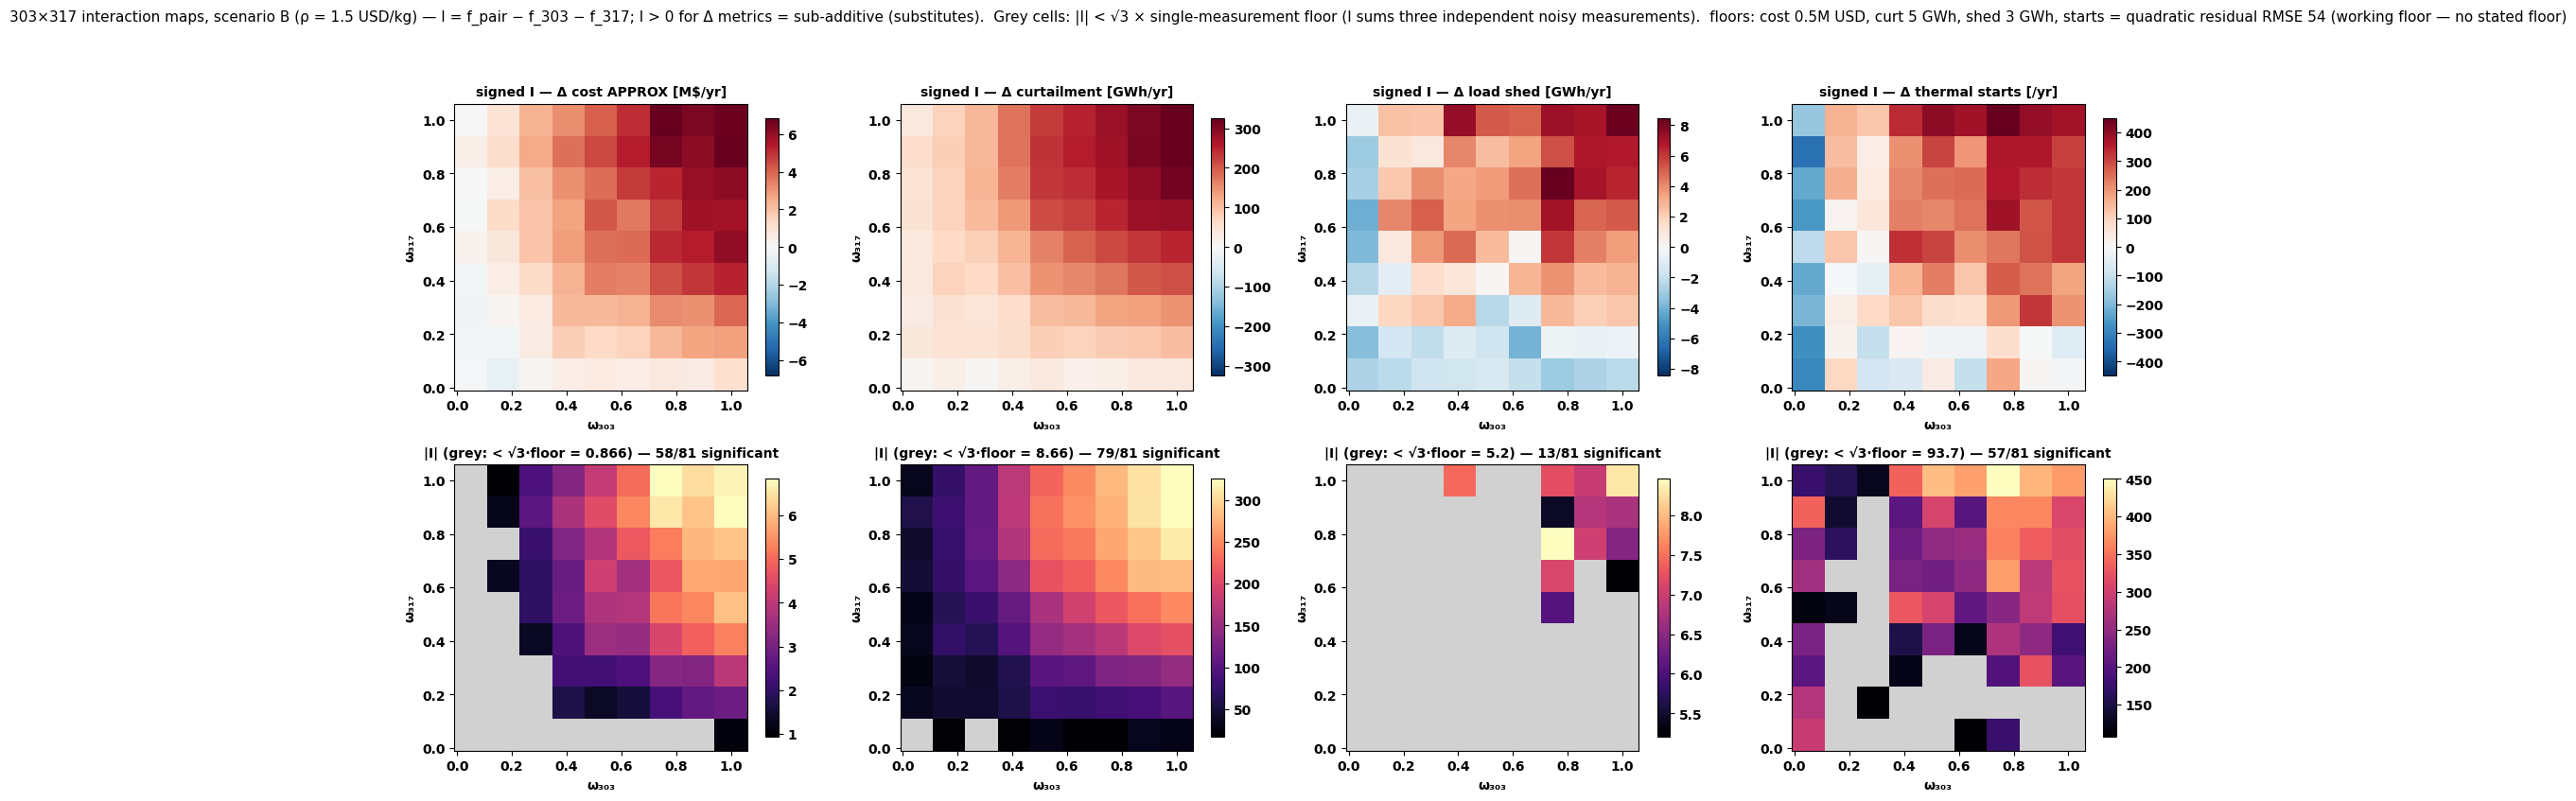

saved figs/interaction_maps_C.png + .pdf


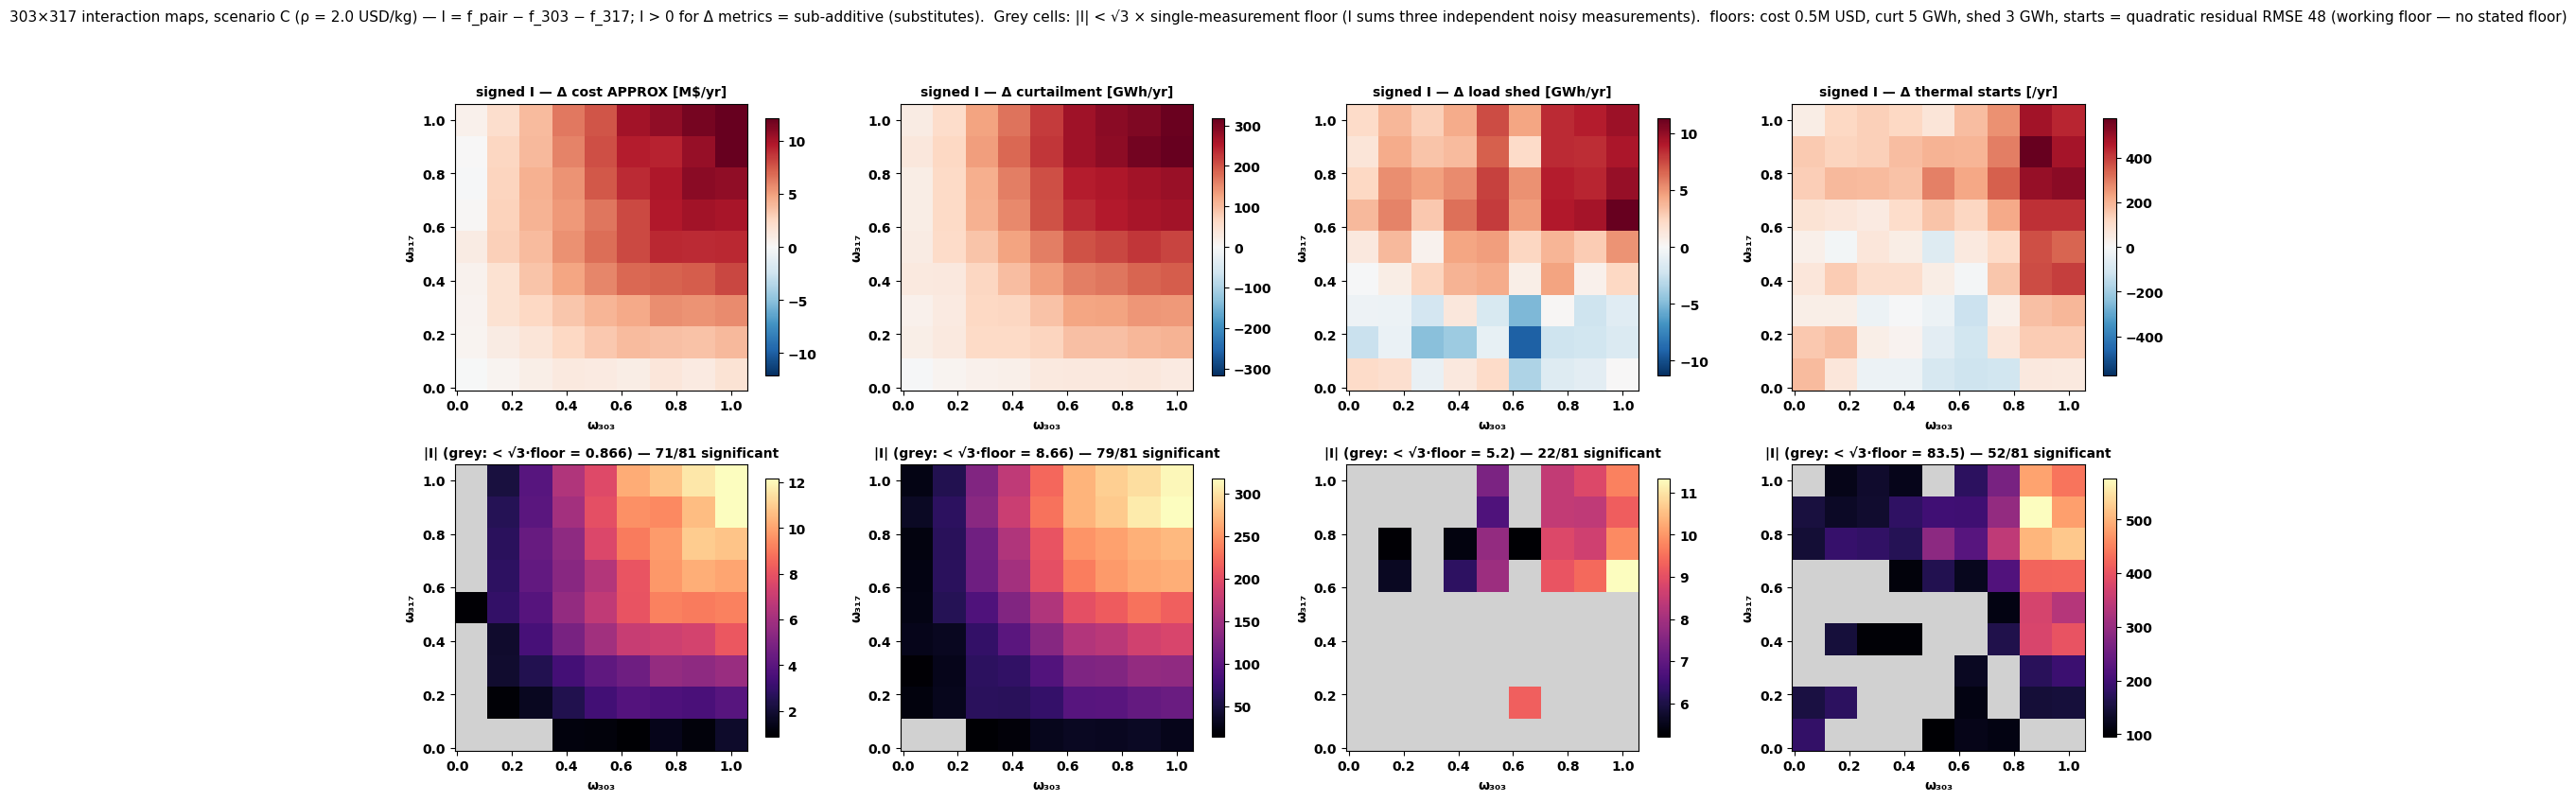

NOTE: no interaction map for scenario A — sweep_A was never run (math-log §4.1 chose ρ = 1.5, 2.0 only), so the A margins f(ω,0) do not exist.


In [5]:
import matplotlib as mpl

for s in SCEN:
    fig, axes = plt.subplots(2, 4, figsize=(19, 8.6))
    for j, col in enumerate(M4):
        label, scale, _ = METRICS[col]
        I = I_maps[(s, col)] * scale
        floor = FLOOR[col] if FLOOR[col] is not None else STARTS_RMSE[s]
        thr = np.sqrt(3) * floor * scale

        axs = axes[0, j]
        m = np.nanmax(np.abs(I))
        pm = axs.pcolormesh(lat303, lat317, I, cmap="RdBu_r", shading="nearest",
                            norm=mpl.colors.TwoSlopeNorm(vmin=-m, vcenter=0, vmax=m))
        fig.colorbar(pm, ax=axs, shrink=0.9)
        axs.set_title(f"signed I — {label.splitlines()[0]}", fontsize=10)

        axa = axes[1, j]
        A = np.abs(I)
        masked = np.ma.masked_where(A < thr, A)
        cmap = mpl.colormaps["magma"].copy(); cmap.set_bad("0.82")
        pm = axa.pcolormesh(lat303, lat317, masked, cmap=cmap, shading="nearest")
        fig.colorbar(pm, ax=axa, shrink=0.9)
        n_sig = int((A >= thr).sum())
        axa.set_title(f"|I| (grey: < √3·floor = {thr:.3g}) — {n_sig}/81 significant",
                      fontsize=10)
        for ax in (axs, axa):
            ax.set_xlabel("ω₃₀₃", fontweight="bold")
        axs.set_ylabel("ω₃₁₇", fontweight="bold"); axa.set_ylabel("ω₃₁₇", fontweight="bold")
    fl = ("floors: cost 0.5M USD, curt 5 GWh, shed 3 GWh, starts = quadratic "
          f"residual RMSE {STARTS_RMSE[s]:.0f} (working floor — no stated floor)")
    fig.suptitle(
        f"303×317 interaction maps, scenario {s} (ρ = {SCEN[s]} USD/kg) — "
        "I = f_pair − f_303 − f_317; I > 0 for Δ metrics = sub-additive "
        f"(substitutes).  Grey cells: |I| < √3 × single-measurement floor "
        f"(I sums three independent noisy measurements).  {fl}",
        fontsize=11)
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    save(fig, f"interaction_maps_{s}")
    plt.show()

print("NOTE: no interaction map for scenario A — sweep_A was never run "
      "(math-log §4.1 chose ρ = 1.5, 2.0 only), so the A margins f(ω,0) "
      "do not exist.")


In [6]:
# where does interaction "turn on"? smallest omega with a significant cell
onset = {}
for (s, col), I in I_maps.items():
    floor = FLOOR[col] if FLOOR[col] is not None else STARTS_RMSE[s]
    sig = np.abs(I) >= np.sqrt(3) * floor
    if sig.any():
        jj, ii = np.where(sig)
        onset[(s, col)] = (lat303[ii.min()], lat317[jj.min()],
                           int(sig.sum()),
                           bool((I[sig] > 0).all()))
    else:
        onset[(s, col)] = (np.nan, np.nan, 0, None)
for k, v in onset.items():
    print(k, "min sig omega303=%.3g, omega317=%.3g, n_sig=%d, all I>0: %s" % v)


('B', 'delta_cost_less_synthetic_usd_APPROX') min sig omega303=0.169, omega317=0.05, n_sig=58, all I>0: True
('B', 'delta_curtailment_mwh') min sig omega303=0.05, omega317=0.05, n_sig=79, all I>0: True
('B', 'delta_load_shed_mwh') min sig omega303=0.406, omega317=0.525, n_sig=13, all I>0: True
('B', 'delta_thermal_starts') min sig omega303=0.05, omega317=0.05, n_sig=57, all I>0: False
('C', 'delta_cost_less_synthetic_usd_APPROX') min sig omega303=0.05, omega317=0.05, n_sig=71, all I>0: True
('C', 'delta_curtailment_mwh') min sig omega303=0.05, omega317=0.05, n_sig=79, all I>0: True
('C', 'delta_load_shed_mwh') min sig omega303=0.169, omega317=0.169, n_sig=22, all I>0: False
('C', 'delta_thermal_starts') min sig omega303=0.05, omega317=0.05, n_sig=52, all I>0: False


In [7]:
# ---- write SWEEP.md ----
def fmt_tab(s):
    rows = []
    for t in TIERS:
        r = [t]
        for col in list(METRICS)[:5]:
            _, scale, _ = METRICS[col]
            q = tables[(s, col)].loc[t]
            sat = "—" if np.isnan(q.sat_omega) else f"{q.sat_omega:.2f}"
            r.append(f"{q.total * scale:,.1f} / {sat}")
        rows.append("| " + " | ".join(r) + " |")
    return "\n".join(rows)

curt_rank_B = " > ".join(RANK[("B", "delta_curtailment_mwh")])
shed_rank_B = " > ".join(RANK[("B", "delta_load_shed_mwh")])
aggB = agg[(agg.scenario == "B") & (agg.metric == "delta_curtailment_mwh")].iloc[0]

sweep_md = f'''# Sweep + interaction findings (prompt 20, data 2026-09-10)

Data: `waves/sweep_B` (ρ=1.5), `waves/sweep_C` (ρ=2.0) — 6 tiers × 9 ω
levels, full-year OAT — and `waves/contour_303x317_B/C` for the pair
surfaces. All Δ vs base year; negative = improvement. Reserve shortfall is
a **diagnostic** (no stated floor), never a headline metric.

## Tier × metric summary (total effect at box top / saturation ω)

Cells: `total / ω_sat`. Units: cost M$ (APPROX), curtailment GWh, shed
GWh, starts count, reserve GWh. ω_sat = first ω where the remaining
improvement is < 10% of the tier's total; "—" = total below noise floor
(saturation undefined).

### Scenario B (ρ = 1.5 $/kg, B = $30)

| tier | Δcost APPROX | Δcurt | Δshed | Δstarts | Δreserve (diag) |
|---|---|---|---|---|---|
{fmt_tab("B")}

### Scenario C (ρ = 2.0 $/kg, B = $40)

| tier | Δcost APPROX | Δcurt | Δshed | Δstarts | Δreserve (diag) |
|---|---|---|---|---|---|
{fmt_tab("C")}

**Nuclear cost caveat (mandatory):** nuclear Δcost is an APPROX-column
value that EXCLUDES the ~$27.8M/yr base-nuclear fuel asymmetry (living
report §3.4) — do not read nuclear's negative Δcost as a cost-negative
retrofit; its true position is ≈ +$13–27M/yr.

## Findings

1. **The wind curtailment ranking is screening's, at both prices:**
   {curt_rank_B} — the same top-heavy order screening measured at B=$40
   (303: 671.6 > 317: 498.7 > 122: 416.6 GWh solo), now traced over the
   whole ω box.
2. **The reliability cluster is led by 317/122, not by curtailment-leader
   303.** Shed ranking {shed_rank_B} at both prices; starts and the
   reserve diagnostic follow the same 317/122-first pattern, with 122
   pulling ahead of 317 on starts and reserve at C. Consistent with 19b's
   committed-capacity reading: withheld *capacity*, not energy, drives
   the cluster, and 303's energy lead does not carry over.
3. **Curtailment is first-order price-invariant; cost is not.** B→C moves
   per-tier Δcurt by ≲5% but adds $1.5–2.6M to every wind tier's Δcost —
   the price scenario prices the same physical diversion differently.
4. **Small tiers are shed-inert:** pv and tail Δshed sit inside the
   ±3 GWh floor at both prices (report as "0 within noise"); their
   curtailment effects (170–284 GWh) are real but 2–5× smaller than any
   single big wind tier.
5. **Wind curtailment shows diminishing returns inside the box:** each
   wind tier reaches 90% of its total effect by ω_sat ≈ 0.76–0.88 (see
   tables) while remaining monotone to ω = 1.0 — the last ~120 MW-scale
   increments of PEM buy the final ~10%. Nuclear and pv saturate earlier
   relative to their (smaller) boxes.
6. **Interactions (§4.3): sub-additive (substitutes) across the
   measurable plane, with one caveated edge.** For curtailment and cost
   the interaction is significant almost everywhere (79/81 and 52–71/81
   cells) and I > 0 in every significant cell, from the smallest ω up.
   Shed interaction only *turns on* at mid-size (first significant cells
   ω ≈ 0.41/0.53 at B; 13–22 cells; all but one I > 0). At (1,1) the
   additive OAT sum overpromises the pair improvement by
   {abs(aggB.rel_pct):.0f}% (curtailment, B; {aggB.I_11/1e3:,.0f} GWh) —
   the two-site share of screening's +54.6% eleven-site gap. Caveat:
   thermal starts shows a band of *negative* I (apparent complementarity,
   −100…−340 starts) along the ω ≈ 0.05 edges in both scenarios; it sits
   just above the *working* floor (quadratic-residual RMSE ≈ 50, no
   established floor), so we flag it as tentative rather than a finding.
   No A-scenario map exists (no sweep_A wave).

## Files

- `sweep_curves.ipynb` (this notebook, executed) — asserts
  6×9×2 + bitwise lattice equality, curves grid, quantification tables,
  interaction maps.
- `figs/sweep_curves_grid.png|pdf`, `figs/interaction_maps_B|C.png|pdf`.
'''
(OUT / "SWEEP.md").write_text(sweep_md)
print("wrote SWEEP.md")


wrote SWEEP.md
